# Objectifs du TP

L'objectif général de ce TP est de mettre en oeuvre le processus d'entraînement d'un réseau de neurones artificiel et de l'appliquer sur la classification d'Iris.

Plus spéfiquement, il s'agira:
* De s'assurer que le processus d'apprentissage d'un réseaux de neurones artificiel est compris, afin de pouvoir le mettre en oeuvre dans un programme.
* Tester un modèle et identifier les types d'erreurs commises par celui-ci.

# 1. Rappels sur les réseaux de neurones artificiels

La figure ci-dessous est un exemple d'architecture que nous pourrons instancier avec notre programme :



<img src="Architecture_reseau.jpg" width="500" alt="Architecture de réseau de neurones"/>

## Questions

1. Combien de couches cachées ce modèle comporte-t-il, et combien chaque couche comporte-t-elle d'unités ?
3. Combien d'attributs constituent un vecteur d'entrée $\mathbf{x}_i$ ?
4. Quelle est la dimension du vecteur $\mathbf{\hat{y}}$ calculé en sortie ?
    * Par rapport au problème à résoudre, à quoi cette dimension correspond-elle ?
6. Comment calcule-t-on $z_i^{[l]}$ ?
7. Comment calcule-t-on $a_i^{[l]}$ ?


8. Que représentent $Z^{[l]}$ et $A^{[l]}$ ?

### Réponses

" Il existe plusieurs types de fonctions d’activation, chacune avec des caractéristiques et des applications spécifiques, comme la fonction Sigmoid, la fonction Tanh (Tangente Hyperbolique) et la fonction ReLU (Rectified Linear Unit)"

1. il ya deux couches cachés. la première couche comporte 3 unités et la deuxième couche 2 unités.

3. on a 4 entrées X1, X2, X3, X4 donc on a 4 attributs pour ce modèle

4. la dimensions du vecteur calculé en sortie est de 3 dimensions.

Par rapport au problème à résoudre dans ce cas précis, ce modèle cherche à prédire l'appartenance d'une fleur d'iris à l'une des trois classes différentes d'iris. Ces trois classes sont typiquement setosa, versicolor et virginica. les valeurs produite par les trois unités de la dernière couche pourraient etre interpreté comme la probabilité d'appartenance à chacune des trois classes 

6.  z^i = w^i * a^i + b^i 

 w^i = weights of layer (poids des couches)
 a^i = activation of layer ()
 b^i = bias of layer (biais des couches)

7. a^i = g(z^i)

g(z^i) = activation function (fonction d'activation)

8. z^i[l] : le vecteur contenant toutes les valeurs de layer

a^i[l] : le vecteur des activations




---
Cette architecture est dite *entièrement connectée* ; autrement dit, chaque unité d'une couche $l$ est connectée à toutes les unités de la couche $l-1$. Les poids des connexions sur chaque couche sont représentés par des matrices $\mathbf{W}^{[l]}$ de dimensions $n_l \times n_{l-1}$ et chaque couche est également associée à un vecteur de biais $\mathbf{b}^{[l]}$ de dimension $n_l \times 1$.

Par exemple, la seconde couche cachée du réseau illustré ci-dessus a pour poids la matrice:
$ \mathbf{W}^{[2]} = 
\begin{pmatrix}
w_{1,1} & w_{2,1} & w_{3,1}\\
w_{2,1} & w_{2,1} & w_{3,1}
\end{pmatrix}
$



## Questions
1. Que représentent $n_l$ et $n_{l-1}$ ?
2. Quelles sont les dimensions des matrices de poids pour $l=1$ et $l = L = 3$ ?

### Réponses

TODO
1. n représente le nombre de neurone de la couche l
 n-1 représente le nombre de neurone de la couche l-1 (couche précédente)

2. pour l = 1 on a W[1] = n1 * n0 donc le nombre de neurone de la couche 1 est égal au produit du nombre de neurone de la couche 0 et du nombre de neurone de la couche 1.

pour l = 3 on a W[3] = n3 * n2 donc le nombre de neurone de la couche 3 est égal au produit du nombre de neurone de la couche 2 et du nombre de neurone de la couche 3.



---
Le processus d'apprentissage est itératif, et constitué des grandes étapes suivantes:
1. Passer en entrée une donnée ou un lot de données et calculer la sortie correspondante.
2. Calculer l'erreur du modèle en évaluant la différence entre $\mathbf{Y}$ et $\mathbf{\hat{Y}}$.
3. Distribuer l'erreur dans chaque unité du réseau par rétropropagation, et mettre à jour les paramètres proportionnellement à la magnitude des connexions à cette unité.
4. Répéter 1, 2 et 3 tant qu'un certain critère d'arrêt n'est pas atteint.

Ces grandes étapes constitue l'algoritme de **rétropropagation du gradient de l'erreur**.

## Questions
1. Qu'entend-on par "lot de données" ?
2. Comment détermine-t-on l'erreur du modèle dans un problème de classification ?
3. Comment exprime-t-on mathématiquement l'idée de "mettre à jour les paramètres proportionnellement à la magnitude des connexions" ?
4. A quoi correspond une "époque" d'entrainement ?
5. Quelle méthode d'arrêt du processus d'apprentissage (qui n'est pas ``while epoch < 100``) pouvons nous mettre en oeuvre ? 
    * Expliquer comment cette méthode fonctionne.

# Prise en main du code

Une base de code est disponible dans le fichier `NeuralNet.py` (que vous pouvez charger comme module dans le présent noteboook), complété d'un fichier utilitaire `Utility.py`.

1. Que représentent les différents attributs du constructeur de la classe ?
2. Comment les paramètres initialisés dans la méthode `__weights_initialization` sont-ils distribués ?
3. Expliquez le processus mis en oeuvre dans la méthode `fit`.
4. À quoi correspondent les fonctions mises en oeuvre dans le fichier `Utility.py`? Que renvoient ces fonction?
5. Dans le test du module, on voit l'instruction suivante:
`X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)`. À quoi correspondent les ensembles "train" et "val" ?
6. Dans la cellule suivante:
    * On voit que le jeu de données est partagé en `X_train`, `X_test` et `X_val`. Expliquez l'utilité de chacun de ces jeux.
    * Que réalise l'instruction suivante: `confusion_mtx, accuracy, metrics = nn.evaluate(X_val, y_val) `? Expliquez les résultats obtenus.

# Mise en oeuvre

La cellule-ci dessous contient le code qui devra pouvoir s'exécuter après avoir complété le corps des méthodes `__feed_forward`, `__backward_pass` et `predict`.

* Epoch 0 -- Error :   Train : 1.1382    Validation : 1.1527
* Epoch 10 -- Error :   Train : 1.0625    Validation : 1.0601
* Epoch 20 -- Error :   Train : 0.9254    Validation : 0.9081
* Epoch 30 -- Error :   Train : 0.7213    Validation : 0.6897
* Epoch 40 -- Error :   Train : 0.6048    Validation : 0.5706
* Epoch 50 -- Error :   Train : 0.5594    Validation : 0.5167
* Epoch 60 -- Error :   Train : 0.5326    Validation : 0.4885
* Epoch 70 -- Error :   Train : 0.5114    Validation : 0.4713
* Epoch 80 -- Error :   Train : 0.5021    Validation : 0.4619
* Epoch 90 -- Error :   Train : 0.5016    Validation : 0.4546


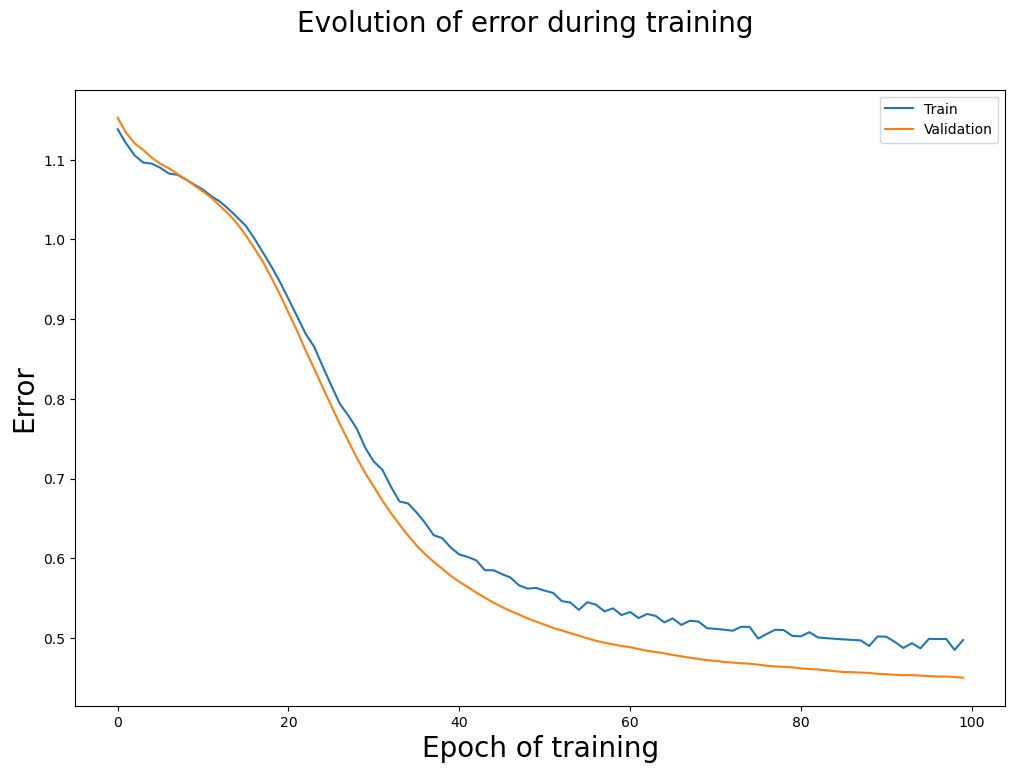

** Instance to predict:
     sepal_length  sepal_width  petal_length  petal_width
110           6.5          3.2           5.1          2.0

** Class:
     Iris-setosa  Iris-versicolor  Iris-virginica
110            0                0               1

Output probabilities:
[[0.01203416 0.48860381 0.49936204]]

** Instance to predict:
    sepal_length  sepal_width  petal_length  petal_width
64           5.6          2.9           3.6          1.3

** Class:
    Iris-setosa  Iris-versicolor  Iris-virginica
64            0                1               0

Output probabilities:
[[0.01629628 0.47679955 0.50690417]]

** Instance to predict:
    sepal_length  sepal_width  petal_length  petal_width
68           6.2          2.2           4.5          1.5

** Class:
    Iris-setosa  Iris-versicolor  Iris-virginica
68            0                1               0

Output probabilities:
[[0.01191438 0.48909028 0.49899535]]

** Instance to predict:
    sepal_length  sepal_width  petal_length  pet

In [1]:
import NeuralNet
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def test_NeuralNet(nn, test_data, test_labels):
    '''
    Tests the neural net on a bunch of random instances
    '''
    if nn == None: return None
    for i in range(4):
        instance = test_data.sample()
        idx = instance.index[0]
        print(f"** Instance to predict:\n{instance}\n")
        print(f"** Class:\n{test_labels.loc[[idx]]}\n")
        y_hat = nn.predict(instance)
        print(f"Output probabilities:\n{y_hat}\n")
    return None

# Load the data
df = pd.read_csv('iris.csv')

# Set a portion of data aside for testing
df_test  = df.sample(frac=0.15, random_state=42) # 22 instances
df_train = df.drop(df_test.index) # 128 instances

# Get attributes and target
target = 'class'
attributes = list(df_train.columns)[:-1] # attributes minus the target

X, X_test = df_train[attributes], df_test[attributes]
y, y_test = df_train[target], df_test[target]
y, y_test = pd.get_dummies(y, dtype='int'), pd.get_dummies(y_test, dtype='int') # one-hot encoding

# Set data aside for validation
X_train, X_val, y_train, y_val = \
    train_test_split(X, y, test_size=0.2, random_state=42)

# Convert dataframes to numpy arrays
X_train, y_train = X_train.to_numpy(), y_train.to_numpy()
X_val, y_val = X_val.to_numpy(), y_val.to_numpy()

# Instanciate and train a neural network
nn = NeuralNet.NeuralNet(hidden_layer_sizes=(3,2), batch_size=4, activation='tanh',
                learning_rate=0.01, epoch=100)
nn.fit(X_train, y_train, X_val, y_val)

# Test the model
test_NeuralNet(nn, X_test, y_test)